In [30]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np

# Import gol_mosaics (installed with: pip install -e .)
from gol_mosaics import MosaicGenerator, ColorScheme, GollyExporter

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


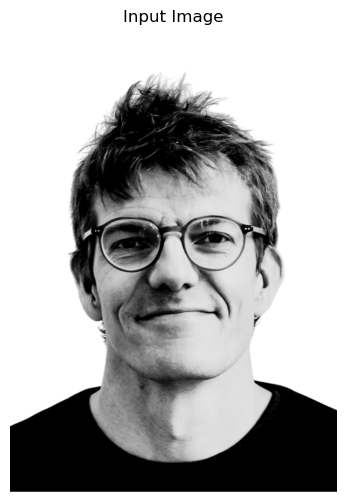

In [31]:
from PIL import Image

# Load input image
input_path = '../input/images/jan.png'
input_image = Image.open(input_path)

# Display
plt.figure(figsize=(6, 6))
plt.imshow(input_image)
plt.title('Input Image')
plt.axis('off')
plt.show()

In [32]:
# Create generator with default settings (level 4, grid size 30, random ECA)
# This will use UGent colors (blue and yellow)

grid_size = 90
generator = MosaicGenerator(grid_size=grid_size)

print(f"Generator created: {generator}")
print()
print(f"Pattern library will be loaded with Still Life Tiles of level {generator.level}")
print(f"Grid height: {generator.grid_size} tiles")
print(f"The background will contain patterns created by the elementary CA with rule {generator.eca_rule}")

Generator created: MosaicGenerator(level=4, grid_size=90, eca_rule=147)

Pattern library will be loaded with Still Life Tiles of level 4
Grid height: 90 tiles
The background will contain patterns created by the elementary CA with rule 147


Generating mosaic...

Done!
Mosaic size: (1104, 1536)
Selected ECA rule: 147


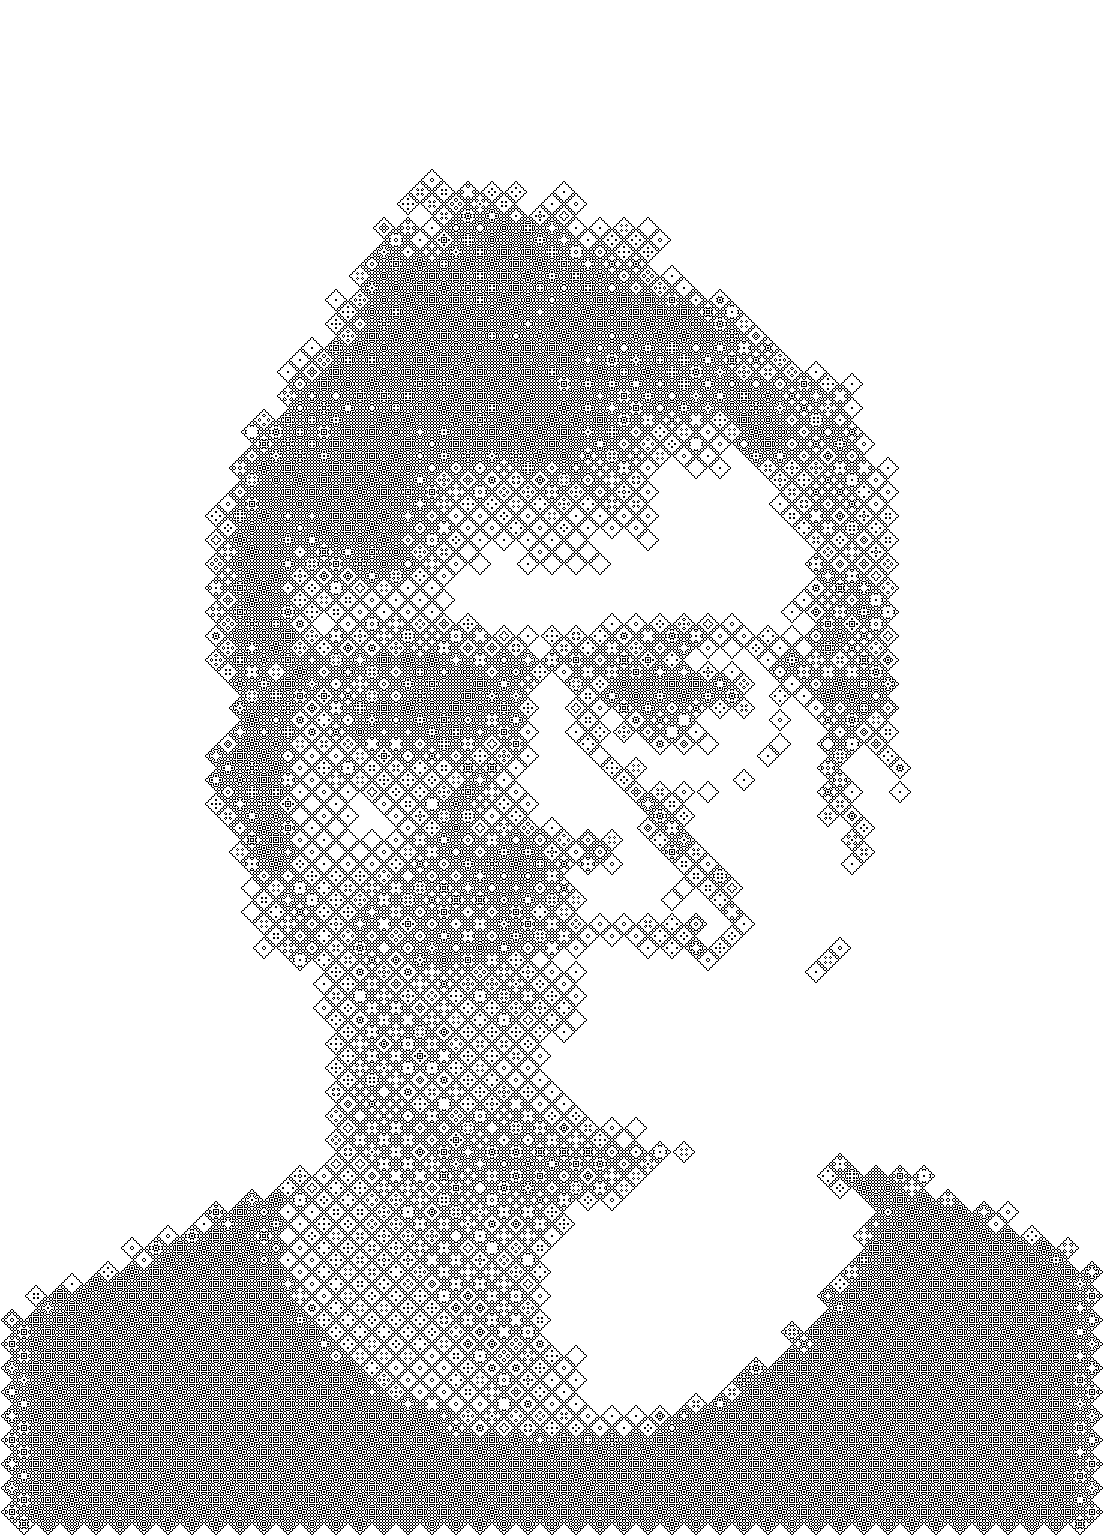

In [33]:
# Generate mosaic (this may take a few seconds)
# No parameters needed - supersample and ECA rule are auto-selected!
print("Generating mosaic...")
print()
mosaic = generator.generate_from_image(input_path, alpha_cutoff=0.)
print(f"Done!")
print(f"Mosaic size: {mosaic.size}")
print(f"Selected ECA rule: {generator.eca_rule}")

mosaic

In [35]:
# export this mosaic as a golly file
mosaic_bool = np.array(mosaic.convert("L")) == 0
exporter = GollyExporter()
add_glider = 'bottom right'

filename = '../output/golly/jan.cells'
exporter.export_to_cells(mosaic_bool, filename=filename, add_glider=add_glider)